In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import os


warnings.filterwarnings("ignore")
%matplotlib inline
plt.style.use('ggplot')
seed = 28  
np.random.seed(seed)

In [3]:
file_path = 'db_pap3.csv'
df = pd.read_csv(file_path)

In [5]:
df.head(5)

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28


In [4]:
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nMissing values percentage:\n{(df.isnull().sum()/len(df)*100).round(2)}")

Dataset shape: (10127, 17)

First 5 rows:
   clientnum  client_stayed  customer_age gender  dependent_count  \
0  768805383              1            45      M                3   
1  818770008              1            49      F                5   
2  713982108              1            51      M                3   
3  769911858              1            40      F                4   
4  709106358              1            40      M                3   

  education_level marital_status     income_category card_category  \
0     High School        Married   5833.333333333333          Blue   
1        Graduate         Single  1666.6666666666667          Blue   
2        Graduate        Married   8333.333333333334          Blue   
3     High School        Unknown  1666.6666666666667          Blue   
4      Uneducated        Married   5833.333333333333          Blue   

   months_on_book  total_relationship_count  months_inactive_12_mon  \
0              39                         5        

In [6]:
print(f"\nNumerical variables statistics:\n{df.describe()}")


Numerical variables statistics:
          clientnum  client_stayed  customer_age  dependent_count  \
count  1.012700e+04   10127.000000  10127.000000     10127.000000   
mean   7.391776e+08       0.839340     46.325960         2.346203   
std    3.690378e+07       0.367235      8.016814         1.298908   
min    7.080821e+08       0.000000     26.000000         0.000000   
25%    7.130368e+08       1.000000     41.000000         1.000000   
50%    7.179264e+08       1.000000     46.000000         2.000000   
75%    7.731435e+08       1.000000     52.000000         3.000000   
max    8.283431e+08       1.000000     73.000000         5.000000   

       months_on_book  total_relationship_count  months_inactive_12_mon  \
count    10127.000000              10127.000000            10127.000000   
mean        35.928409                  3.812580                2.341167   
std          7.986416                  1.554408                1.010622   
min         13.000000                  1.0000

### DESCRIPTIVE AND GROUPED EDA

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical variables unique values:\n{df[categorical_cols].nunique()}")


Categorical variables unique values:
gender             2
education_level    7
marital_status     4
income_category    6
card_category      4
dtype: int64


In [8]:
print(f"\nTarget variable distribution (client_stayed):")
print(df['client_stayed'].value_counts(normalize=True)*100)


Target variable distribution (client_stayed):
client_stayed
1    83.934038
0    16.065962
Name: proportion, dtype: float64


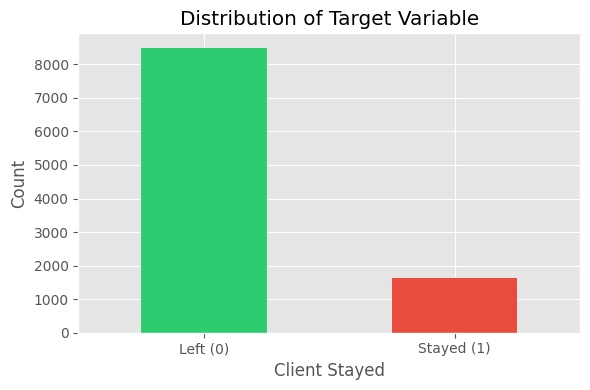

In [9]:
# Visualization: Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['client_stayed'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xlabel('Client Stayed')
ax.set_ylabel('Count')
ax.set_title('Distribution of Target Variable')
ax.set_xticklabels(['Left (0)', 'Stayed (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('clientnum')

for col in numerical_cols:
    if col != 'client_stayed':
        grouped = df.groupby('client_stayed')[col].agg(['mean', 'std', 'median', 'count'])
        print(f"\n{col}:")
        print(grouped)


customer_age:
                    mean       std  median  count
client_stayed                                    
0              46.659496  7.665652    47.0   1627
1              46.262118  8.081157    46.0   8500

dependent_count:
                   mean       std  median  count
client_stayed                                   
0              2.402581  1.275010     2.0   1627
1              2.335412  1.303229     2.0   8500

months_on_book:
                    mean       std  median  count
client_stayed                                    
0              36.178242  7.796548    36.0   1627
1              35.880588  8.021810    36.0   8500

total_relationship_count:
                   mean       std  median  count
client_stayed                                   
0              3.279656  1.577782     3.0   1627
1              3.914588  1.528949     4.0   8500

months_inactive_12_mon:
                   mean       std  median  count
client_stayed                                   
0       

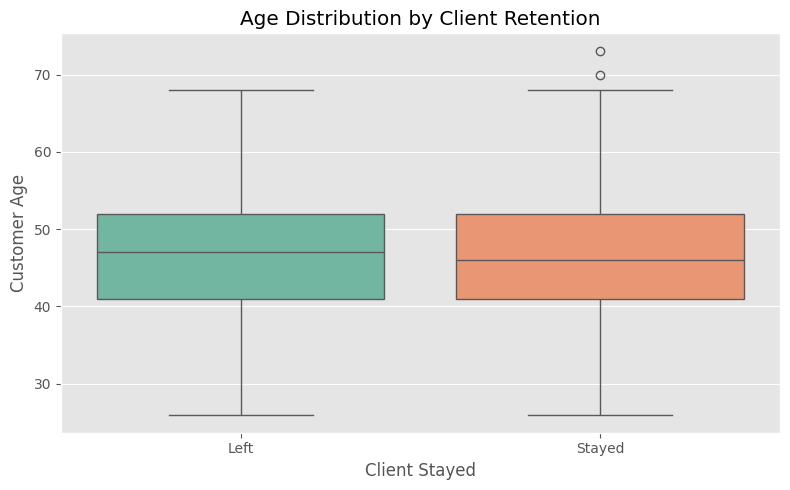

In [11]:
# Age vs Client Stayed
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='client_stayed', y='customer_age', data=df, ax=ax, palette='Set2')
ax.set_xlabel('Client Stayed')
ax.set_ylabel('Customer Age')
ax.set_title('Age Distribution by Client Retention')
ax.set_xticklabels(['Left', 'Stayed'])
plt.tight_layout()
plt.show()

In [12]:
# Income category vs Client Stayed
print(f"\nIncome Category vs Client Stayed:")
income_stay = df.groupby(['income_category', 'client_stayed']).size().unstack(fill_value=0)
income_stay_pct = income_stay.div(income_stay.sum(axis=1), axis=0)*100
print(income_stay_pct.round(2))


Income Category vs Client Stayed:
client_stayed           0      1
income_category                 
10000.0             17.33  82.67
1666.6666666666667  17.19  82.81
4166.666666666667   15.14  84.86
5833.333333333333   13.48  86.52
8333.333333333334   15.77  84.23
Unknown             16.82  83.18


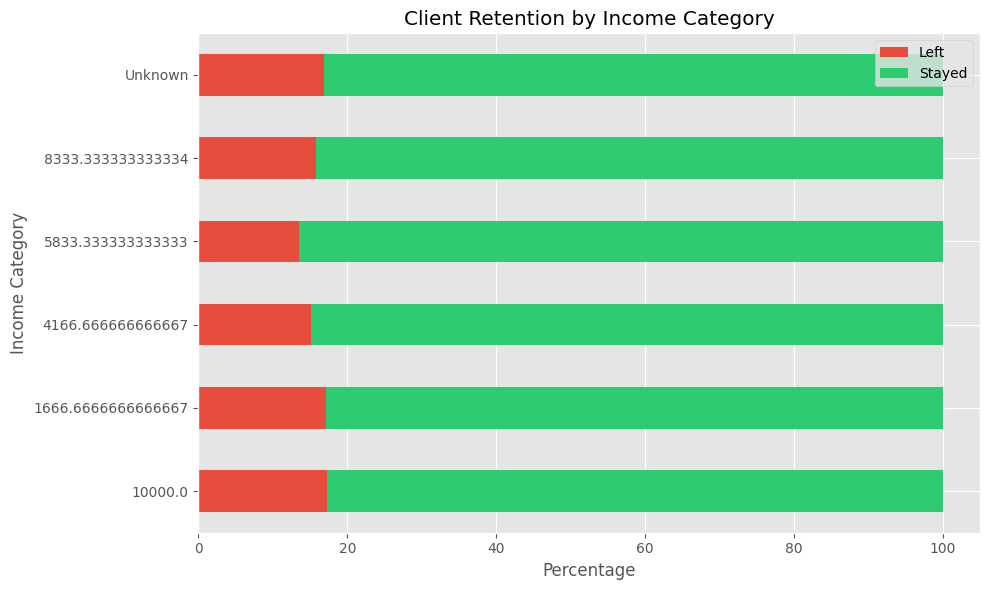

In [13]:
# visualise
fig, ax = plt.subplots(figsize=(10, 6))
income_stay_pct.plot(kind='barh', stacked=True, ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xlabel('Percentage')
ax.set_ylabel('Income Category')
ax.set_title('Client Retention by Income Category')
ax.legend(['Left', 'Stayed'])
plt.tight_layout()
plt.show()

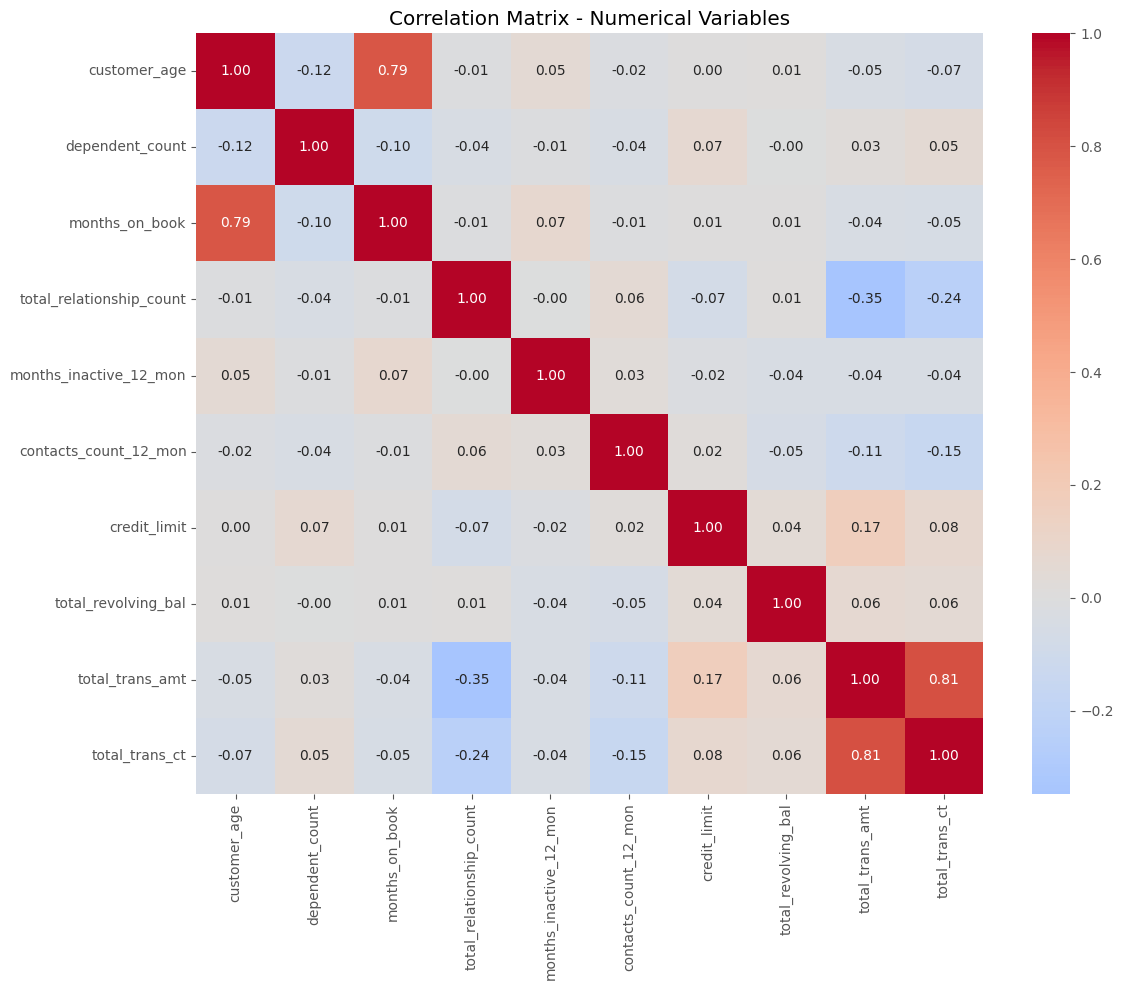

In [16]:
numerical_df = df.select_dtypes(include=[np.number]).drop(columns=['clientnum', 'client_stayed'])
corr_matrix = numerical_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0)
ax.set_title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

In [17]:
target_corr = df.select_dtypes(include=[np.number]).corr()['client_stayed'].sort_values(ascending=False)
print(f"\nCorrelation with target variable (client_stayed):")
print(target_corr)


Correlation with target variable (client_stayed):
client_stayed               1.000000
total_trans_ct              0.371403
total_revolving_bal         0.263053
total_trans_amt             0.168598
total_relationship_count    0.150005
clientnum                   0.046430
credit_limit                0.023873
months_on_book             -0.013687
customer_age               -0.018203
dependent_count            -0.018991
months_inactive_12_mon     -0.152449
contacts_count_12_mon      -0.204491
Name: client_stayed, dtype: float64


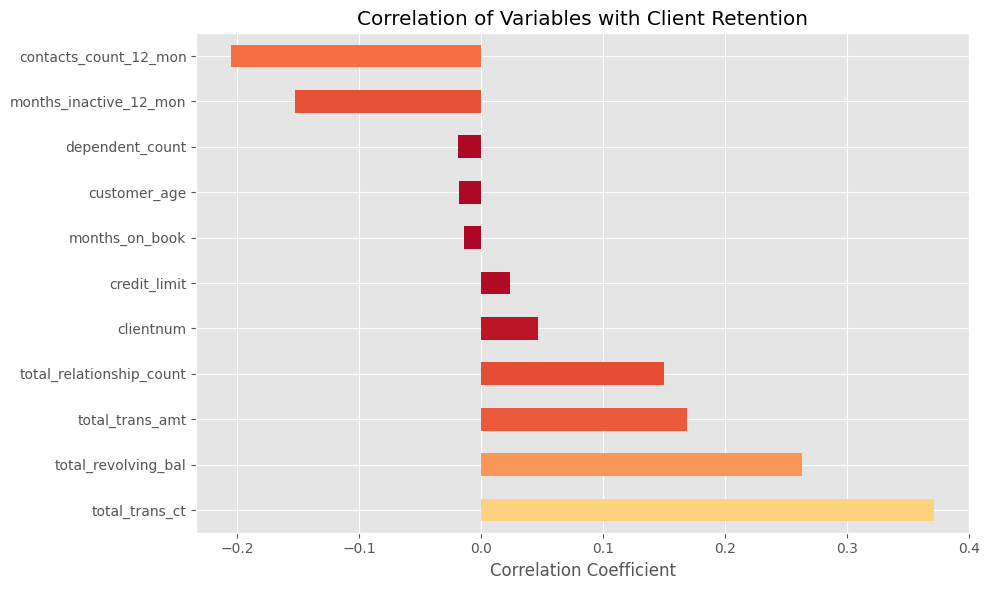

In [18]:
# Visualization: Top correlations with target
fig, ax = plt.subplots(figsize=(10, 6))
target_corr.drop('client_stayed').plot(kind='barh', ax=ax, color=plt.cm.RdYlGn(np.abs(target_corr.drop('client_stayed'))))
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Correlation of Variables with Client Retention')
plt.tight_layout()
plt.show()

## 3.1 Handle missing values

In [19]:
missing_summary = df.isnull().sum()[df.isnull().sum() > 0]
print(missing_summary)

Series([], dtype: int64)


In [20]:
df_clean = df.copy()

In [21]:
numerical_with_missing = [col for col in df_clean.select_dtypes(include=[np.number]).columns 
                          if df_clean[col].isnull().any() and col not in ['clientnum', 'client_stayed']]

for col in numerical_with_missing:
    median_val = df_clean[col].median()
    df_clean[f'{col}_imputed'] = df_clean[col].fillna(median_val)
    print(f"{col}: Filled {df_clean[col].isnull().sum()} missing values with median={median_val:.2f}")

In [22]:
# 3.3 Fill missing values - Categorical columns
categorical_with_missing = [col for col in df_clean.select_dtypes(include=['object']).columns 
                            if df_clean[col].isnull().any()]

for col in categorical_with_missing:
    mode_val = df_clean[col].mode()[0]
    df_clean[f'{col}_imputed'] = df_clean[col].fillna(mode_val)
    print(f"{col}: Filled {df_clean[col].isnull().sum()} missing values with mode='{mode_val}'")

In [26]:
if 'credit_limit' in numerical_with_missing:
    original = df['credit_limit'].dropna()
    imputed = df_clean['credit_limit_imputed']
    
    print(f"\nCredit Limit - Before vs After Imputation:")
    print(f"Original - Mean: {original.mean():.2f}, Std: {original.std():.2f}")
    print(f"Imputed  - Mean: {imputed.mean():.2f}, Std: {imputed.std():.2f}")
    
    # Distribution comparison
    fig, ax = plt.subplots(figsize=(8, 5))
    original.plot(kind='hist', bins=30, alpha=0.5, label='Original', ax=ax, density=True)
    imputed.plot(kind='hist', bins=30, alpha=0.5, label='Imputed', ax=ax, density=True)
    ax.set_xlabel('Credit Limit')
    ax.set_ylabel('Density')
    ax.set_title('Distribution: Original vs Imputed')
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_temp = df.copy()
    df_temp['credit_limit_imputed'] = imputed
    orig_corr = df_temp.dropna(subset=['credit_limit'])['credit_limit'].corr(df_temp.dropna(subset=['credit_limit'])['client_stayed'])
    imp_corr = df_temp['credit_limit_imputed'].corr(df_temp['client_stayed'])
    print(f"Correlation with target - Original: {orig_corr:.4f}, Imputed: {imp_corr:.4f}")

## # 3.5 Encode categorical variables

In [27]:
le_gender = LabelEncoder()
df_clean['gender_encoded'] = le_gender.fit_transform(df_clean['gender_imputed' if 'gender_imputed' in df_clean.columns else 'gender'])
print(f"Gender encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

Gender encoding: {'F': np.int64(0), 'M': np.int64(1)}


In [28]:
categorical_to_encode = ['education_level', 'marital_status', 'income_category', 'card_category']
for col in categorical_to_encode:
    col_name = col if f'{col}_imputed' not in df_clean.columns else f'{col}_imputed'
    dummies = pd.get_dummies(df_clean[col_name], prefix=col, drop_first=True)
    df_clean = pd.concat([df_clean, dummies], axis=1)
    print(f"Created {len(dummies.columns)} dummy variables for {col}")

Created 6 dummy variables for education_level
Created 3 dummy variables for marital_status
Created 5 dummy variables for income_category
Created 3 dummy variables for card_category


## 4. FEATURE ENGINEERING

In [29]:
df_clean['avg_trans_value'] = df_clean['total_trans_amt'] / (df_clean['total_trans_ct'] + 1)  # +1 to avoid division by zero
print(f"Feature 1 - avg_trans_value: Average transaction amount per transaction")
print(f"  Correlation with target: {df_clean['avg_trans_value'].corr(df_clean['client_stayed']):.4f}")

Feature 1 - avg_trans_value: Average transaction amount per transaction
  Correlation with target: -0.0094


In [30]:
df_clean['credit_utilization'] = df_clean['total_revolving_bal'] / (df_clean['credit_limit'] + 1)
print(f"Feature 2 - credit_utilization: Ratio of revolving balance to credit limit")
print(f"  Correlation with target: {df_clean['credit_utilization'].corr(df_clean['client_stayed']):.4f}")

Feature 2 - credit_utilization: Ratio of revolving balance to credit limit
  Correlation with target: 0.1784


In [31]:
df_clean['activity_score'] = (12 - df_clean['months_inactive_12_mon']) * (df_clean['contacts_count_12_mon'] + 1)
print(f"Feature 3 - activity_score: Combined metric of activity and engagement")
print(f"  Correlation with target: {df_clean['activity_score'].corr(df_clean['client_stayed']):.4f}")

Feature 3 - activity_score: Combined metric of activity and engagement
  Correlation with target: -0.1416


In [32]:
df_clean['products_per_month'] = df_clean['total_relationship_count'] / (df_clean['months_on_book'] + 1)
print(f"Feature 4 - products_per_month: Bank products per month of relationship")
print(f"  Correlation with target: {df_clean['products_per_month'].corr(df_clean['client_stayed']):.4f}")

Feature 4 - products_per_month: Bank products per month of relationship
  Correlation with target: 0.1287


In [35]:
df_clean['age_income_interaction'] = df_clean['customer_age'] * df_clean['income_category'].map(
    {'Less than $40K': 1, '$40K - $60K': 2, '$60K - $80K': 3, '$80K - $120K': 4, 
     '$120K +': 5, 'Unknown': 0}).fillna(0)
print(f"Feature 5 - age_income_interaction: Interaction between age and income level")
print(f"  Correlation with target: {df_clean['age_income_interaction'].corr(df_clean['client_stayed']):.4f}")

Feature 5 - age_income_interaction: Interaction between age and income level
  Correlation with target: nan


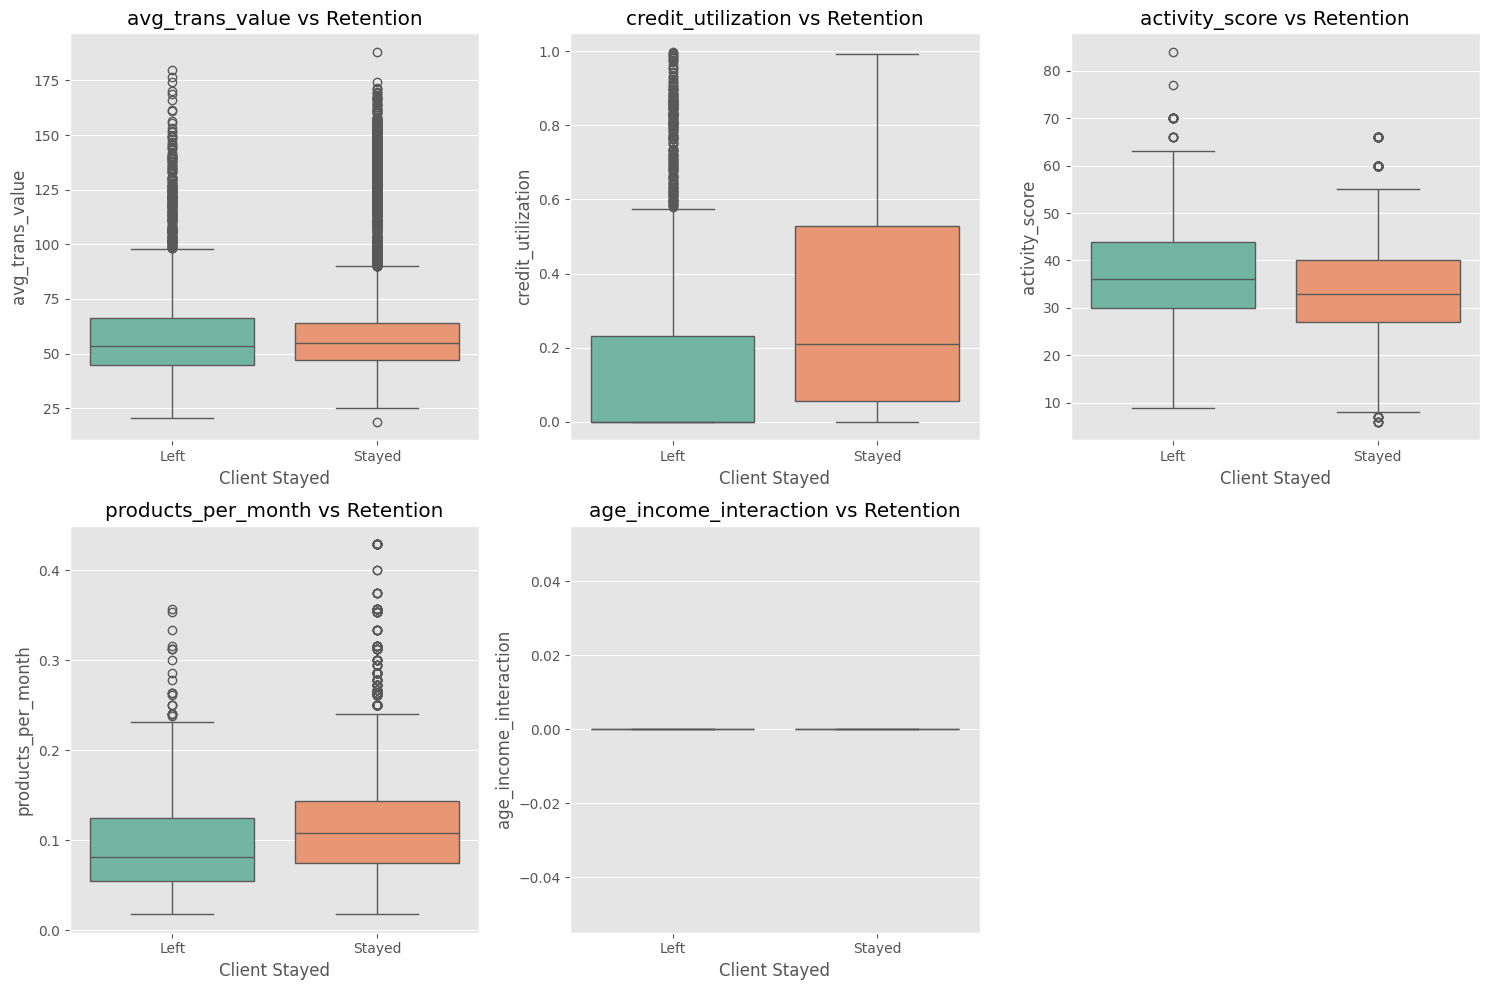

In [36]:
# Visualization: New features vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
new_features = ['avg_trans_value', 'credit_utilization', 'activity_score', 
                'products_per_month', 'age_income_interaction']

for idx, feat in enumerate(new_features):
    ax = axes[idx//3, idx%3]
    sns.boxplot(x='client_stayed', y=feat, data=df_clean, ax=ax, palette='Set2')
    ax.set_xlabel('Client Stayed')
    ax.set_ylabel(feat)
    ax.set_xticklabels(['Left', 'Stayed'])
    ax.set_title(f'{feat} vs Retention')

# Hide unused subplot
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()